# Does Polymarket Lead the News Cycle?

**Research question:** Do Polymarket prediction-market prices move *before* news articles and Reddit posts, or do they react *after*?

**Data sources**
| Dataset | File | Period |
|---|---|---|
| Polymarket YES-prices | `crude_oil_prices.csv` | Feb 28 – Mar 28, 2026 (hourly) |
| NYMEX CL futures | `CL_F_30m.csv` | Mar 1 – Mar 27, 2026 (30-min) |
| yFinance news | `data/raw/news/oil.csv` | Mar 24 – Mar 28, 2026 |
| Reddit posts | `data/raw/reddit/oil.csv` | Feb 28 – Mar 28, 2026 |

**Sections**
1. Load & align data  
2. Polymarket vs NYMEX price  
3. News events overlay  
4. Reddit activity as a signal  
5. Lead-lag cross-correlation  
6. Summary

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (16, 5)})
ROOT = Path("../data/raw")

# ── 1A  Polymarket ─────────────────────────────────────────────────────────────
pm_raw = pd.read_csv(ROOT / "polymarket/crude_oil_prices.csv",
                     parse_dates=["timestamp"])
pm_raw["timestamp"] = pd.to_datetime(pm_raw["timestamp"], utc=True)
pm_raw["strike_val"] = pm_raw["strike"].str.replace("$","",regex=False).astype(int)

# ── 1B  NYMEX 30-min ──────────────────────────────────────────────────────────
nymex = pd.read_csv(ROOT / "nymex/CL_F_30m.csv", parse_dates=["timestamp"])
nymex["timestamp"] = pd.to_datetime(nymex["timestamp"], utc=True)
nymex = nymex.set_index("timestamp").sort_index()

# ── 1C  News ──────────────────────────────────────────────────────────────────
news = pd.read_csv(ROOT / "news/oil.csv", parse_dates=["published_utc"])
news["published_utc"] = pd.to_datetime(news["published_utc"], utc=True)
news = news.sort_values("published_utc")

# ── 1D  Reddit ────────────────────────────────────────────────────────────────
reddit = pd.read_csv(ROOT / "reddit/oil.csv", parse_dates=["published_utc"])
reddit["published_utc"] = pd.to_datetime(reddit["published_utc"], utc=True)
reddit = reddit.sort_values("published_utc")

print(f"Polymarket : {len(pm_raw):>6,} rows | {pm_raw['strike_val'].nunique()} strikes")
print(f"NYMEX 30m  : {len(nymex):>6,} rows | {nymex.index.min().date()} → {nymex.index.max().date()}")
print(f"News       : {len(news):>6,} rows | {news['published_utc'].min().date()} → {news['published_utc'].max().date()}")
print(f"Reddit     : {len(reddit):>6,} rows | {reddit['published_utc'].min().date()} → {reddit['published_utc'].max().date()}")

Polymarket : 69,342 rows | 21 strikes
NYMEX 30m  :    920 rows | 2026-03-01 → 2026-03-27
News       :     37 rows | 2026-03-24 → 2026-03-28
Reddit     :    221 rows | 2026-02-28 → 2026-03-28


In [7]:

# ── Helper: resampled hourly Polymarket series for one strike ─────────────────
def pm_series(strike: int, direction: str = "up") -> pd.Series:
    mask = (pm_raw["strike_val"] == strike) & (pm_raw["direction"] == direction)
    s = (pm_raw[mask].set_index("timestamp")["price"]
         .sort_index().resample("1h").last().ffill())
    s.name = f"PM {direction} ${strike}"
    return s

# ── Helper: NYMEX resampled to 1-hour close ───────────────────────────────────
nymex_1h = nymex["close"].resample("1h").last().ffill()
nymex_1h.name = "NYMEX close"

# ── Helper: Reddit hourly post count ─────────────────────────────────────────
reddit_hourly = (reddit.set_index("published_utc")
                 .resample("1h").size()
                 .rename("reddit_posts"))

# ── Helper: aligned DataFrame for a focal strike ─────────────────────────────
def make_aligned(strike: int, direction: str = "up") -> pd.DataFrame:
    pm = pm_series(strike, direction)
    df = pd.concat([pm, nymex_1h, reddit_hourly], axis=1).dropna(subset=[pm.name])
    df["reddit_posts"] = df["reddit_posts"].fillna(0).astype(int)
    df["nymex_pct_chg"] = df["NYMEX close"].pct_change()
    df["pm_chg"]        = df[pm.name].diff()
    return df

# ── Focal parameters ──────────────────────────────────────────────────────────
# Choose a strike + direction that has full coverage (Feb 28 – Mar 28) so it
# overlaps with ALL data sources including late-March news.
#   Full-coverage examples:  down $40–65,  up $100–200
#   "down $65" = P(CL < $65 by end-March) — nearest below-current-price contract
STRIKE_FOCAL = 65
DIRECTION    = "down"     # "up" or "down"

df = make_aligned(STRIKE_FOCAL, DIRECTION)
print(f"Focal: {DIRECTION!r} ${STRIKE_FOCAL}  |  PM series: {df.index.min().date()} → {df.index.max().date()}  "
      f"({len(df)} hourly rows)")
print(df.tail(3))


Focal: 'down' $65  |  PM series: 2026-02-28 → 2026-03-28  (667 hourly rows)
                           PM down $65  NYMEX close  reddit_posts  \
2026-03-28 11:00:00+00:00       0.0035          NaN             0   
2026-03-28 12:00:00+00:00       0.0030          NaN             1   
2026-03-28 13:00:00+00:00       0.0030          NaN             0   

                           nymex_pct_chg  pm_chg  
2026-03-28 11:00:00+00:00            0.0  0.0005  
2026-03-28 12:00:00+00:00            0.0 -0.0005  
2026-03-28 13:00:00+00:00            0.0  0.0000  


/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_78387/219588450.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["nymex_pct_chg"] = df["NYMEX close"].pct_change()


## 2 · Polymarket vs NYMEX Price

The chart below shows how the Polymarket implied probability tracks the real futures price.  
A rising PM probability = market believes oil will hit the strike by end of March.

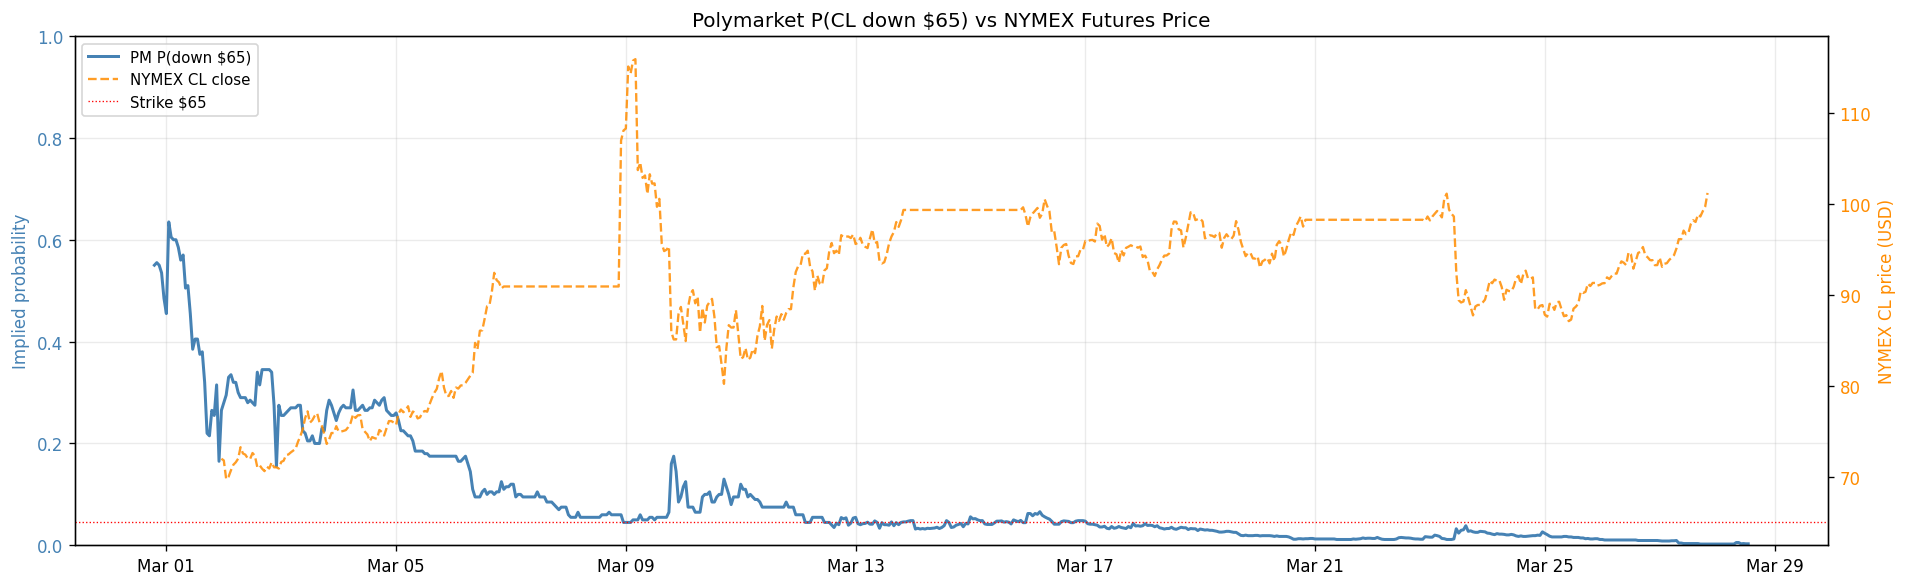

Pearson correlation  PM ↔ NYMEX : -0.873


In [8]:

col_pm    = f"PM {DIRECTION} ${STRIKE_FOCAL}"
col_nymex = "NYMEX close"

fig, ax1 = plt.subplots(figsize=(16, 5))

# Polymarket probability (left axis)
ax1.plot(df.index, df[col_pm], color="steelblue", linewidth=1.8,
         label=f"PM P({DIRECTION} ${STRIKE_FOCAL})")
ax1.set_ylabel("Implied probability", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_ylim(0, 1)

# NYMEX price (right axis)
ax2 = ax1.twinx()
ax2.plot(df.index, df[col_nymex], color="darkorange", linewidth=1.4,
         linestyle="--", label="NYMEX CL close", alpha=0.85)
ax2.set_ylabel("NYMEX CL price (USD)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# Strike line
ax2.axhline(STRIKE_FOCAL, color="red", linewidth=0.8, linestyle=":",
            label=f"Strike ${STRIKE_FOCAL}")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.grid(alpha=0.25)
lines  = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize=9, loc="upper left")
ax1.set_title(f"Polymarket P(CL {DIRECTION} ${STRIKE_FOCAL}) vs NYMEX Futures Price", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/pm_vs_nymex.png", dpi=150)
plt.show()

corr = df[[col_pm, col_nymex]].dropna().corr().iloc[0, 1]
print(f"Pearson correlation  PM ↔ NYMEX : {corr:.3f}")


## 3 · News Events Overlay

Each vertical line is a published news article. We look for PM probability moves that happened *before* the line — evidence that Polymarket anticipated the news.

/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_78387/219588450.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["nymex_pct_chg"] = df["NYMEX close"].pct_change()


PM window: 2026-02-28 → 2026-03-28   News in range: 37


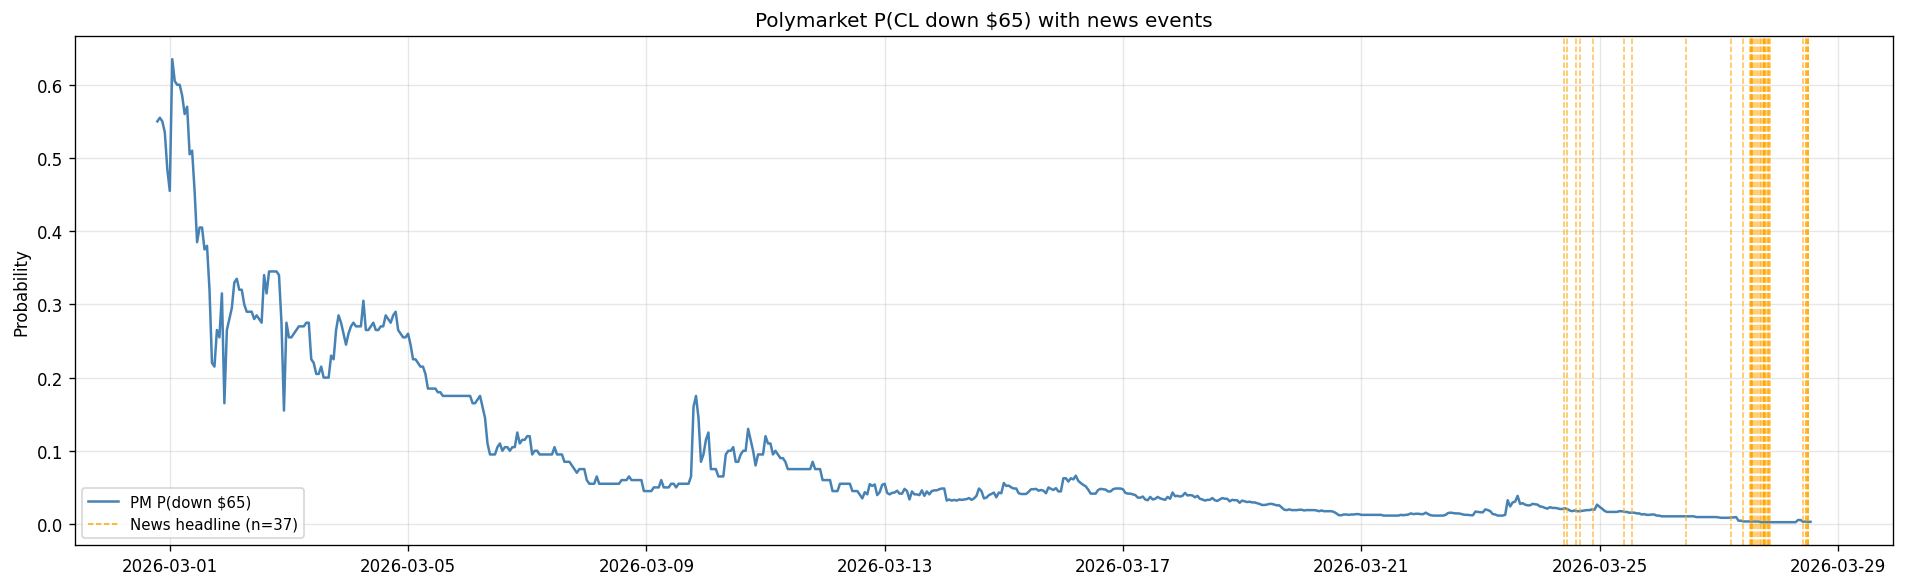


PM Δprobability around each news event:
            published_utc                                                      headline  pm_chg_pre_4h  pm_chg_post_4h
2026-03-24 09:41:53+00:00 Gold and silver price higher amid inflation and interest rat…        -0.0015         -0.0040
2026-03-24 10:52:12+00:00 Pound dips against dollar with mounting expectations of bank…         0.0000         -0.0020
2026-03-24 14:31:29+00:00 Oil price spotlight: What Polymarket says about Strait of Ho…        -0.0020          0.0010
2026-03-24 16:03:35+00:00 Expect 'moderate' hit to US economic growth from Iran war: N…         0.0000          0.0010
2026-03-24 21:10:39+00:00 How the Fed has (and hasn't) reacted to oil shocks in the pa…         0.0015          0.0015
2026-03-25 10:00:11+00:00 How oil, gas price shocks translate into more inflation: Eco…         0.0000         -0.0010
2026-03-25 13:13:35+00:00 Top tips for travelers navigating airport delays, rising air…        -0.0010         -0.0025
2026-03

In [9]:

# ── Section 3: News Events Overlay ──────────────────────────────────────────
WINDOW_H   = 4   # hours each side
df_aligned = make_aligned(STRIKE_FOCAL, DIRECTION)
col_pm     = f"PM {DIRECTION} ${STRIKE_FOCAL}"
col_nymex  = "NYMEX close"

t_start = df_aligned.index.min()
t_end   = df_aligned.index.max()
news_in_range = news[
    (news["published_utc"] >= t_start) & (news["published_utc"] <= t_end)
].copy()
print(f"PM window: {t_start.date()} → {t_end.date()}   News in range: {len(news_in_range)}")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_aligned.index, df_aligned[col_pm], color="steelblue", lw=1.5,
        label=f"PM P({DIRECTION} ${STRIKE_FOCAL})")
for _, row in news_in_range.iterrows():
    ax.axvline(row["published_utc"], color="orange", alpha=0.7, lw=0.9, linestyle="--")

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color="steelblue", lw=1.5, label=f"PM P({DIRECTION} ${STRIKE_FOCAL})"),
    Line2D([0],[0], color="orange",    lw=0.9, linestyle="--",
           label=f"News headline (n={len(news_in_range)})"),
]
ax.legend(handles=handles, fontsize=9)
ax.set_ylabel("Probability", fontsize=10)
ax.set_title(f"Polymarket P(CL {DIRECTION} ${STRIKE_FOCAL}) with news events", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/pm_news_overlay.png", dpi=150)
plt.show()

# ── Pre/post window analysis ─────────────────────────────────────────────────
if len(news_in_range) == 0:
    print("No news articles fall in the PM date window — avg_pre/post = NaN")
    avg_pre = avg_post = float("nan")
else:
    rows_event = []
    for _, nrow in news_in_range.iterrows():
        t    = nrow["published_utc"]
        pre  = df_aligned.loc[(df_aligned.index >= t - pd.Timedelta(hours=WINDOW_H)) &
                              (df_aligned.index <  t), col_pm]
        post = df_aligned.loc[(df_aligned.index >  t) &
                              (df_aligned.index <= t + pd.Timedelta(hours=WINDOW_H)), col_pm]
        pre_chg  = (pre.iloc[-1]  - pre.iloc[0])  if len(pre)  > 1 else float("nan")
        post_chg = (post.iloc[-1] - post.iloc[0]) if len(post) > 1 else float("nan")
        rows_event.append({
            "published_utc": t,
            "headline":      nrow["title"][:60] + "…" if len(nrow["title"]) > 60 else nrow["title"],
            f"pm_chg_pre_{WINDOW_H}h":  round(pre_chg, 4),
            f"pm_chg_post_{WINDOW_H}h": round(post_chg, 4),
        })

    event_df = pd.DataFrame(rows_event)
    print("\nPM Δprobability around each news event:")
    print(event_df.to_string(index=False))
    avg_pre  = event_df[f"pm_chg_pre_{WINDOW_H}h"].mean()
    avg_post = event_df[f"pm_chg_post_{WINDOW_H}h"].mean()

print(f"\nAvg PM Δprob pre-news  ({WINDOW_H}h): {avg_pre:+.4f}")
print(f"Avg PM Δprob post-news ({WINDOW_H}h): {avg_post:+.4f}")
if not (pd.isna(avg_pre) or pd.isna(avg_post)):
    print("→ Polymarket appears to", "LEAD" if abs(avg_pre) > abs(avg_post) else "LAG", "the news.")


## 4 · Reddit Activity as a Signal

Hourly Reddit post count overlaid on the Polymarket probability curve. Does a spike in discussion precede a PM move?

/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_78387/219588450.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["nymex_pct_chg"] = df["NYMEX close"].pct_change()


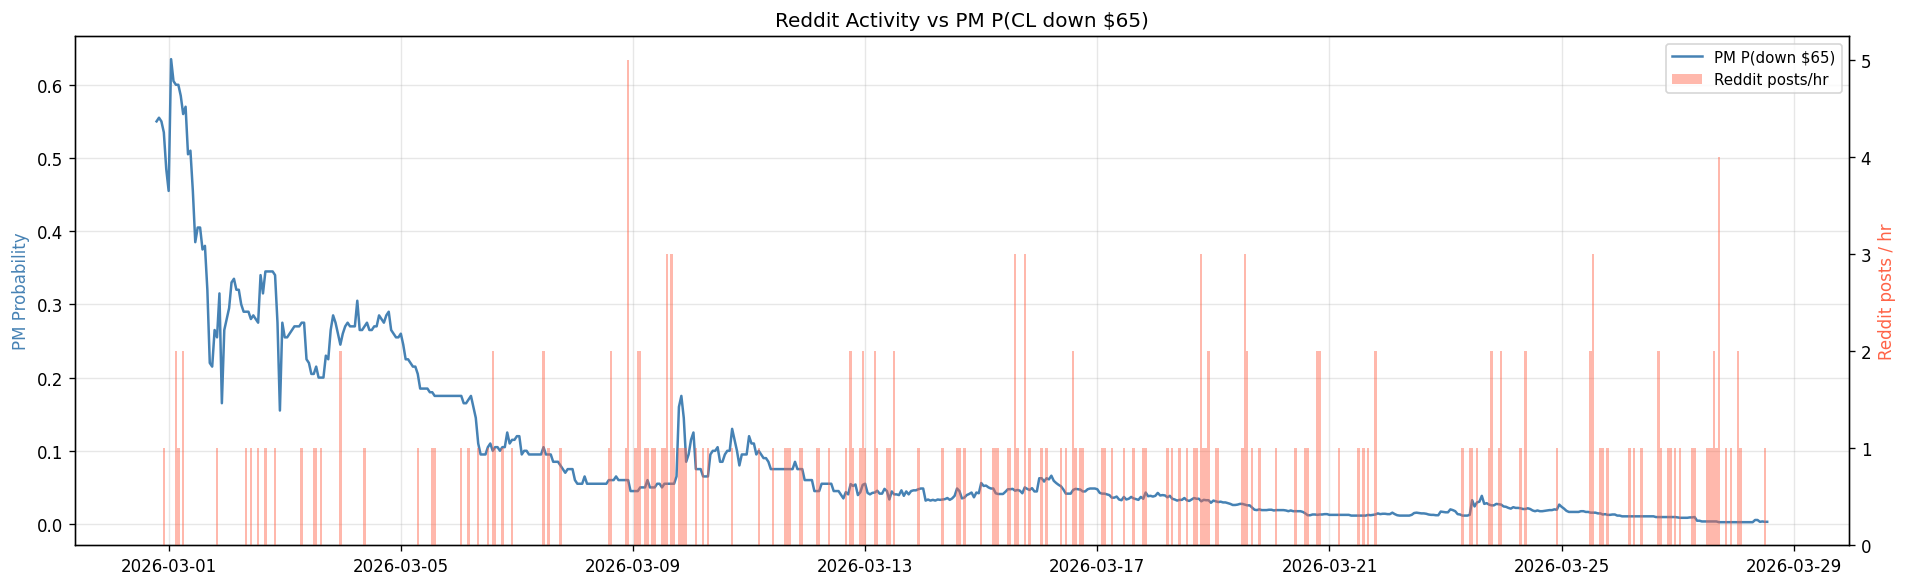

Correlation: Reddit posts/hr  →  PM change next hour: +0.0037


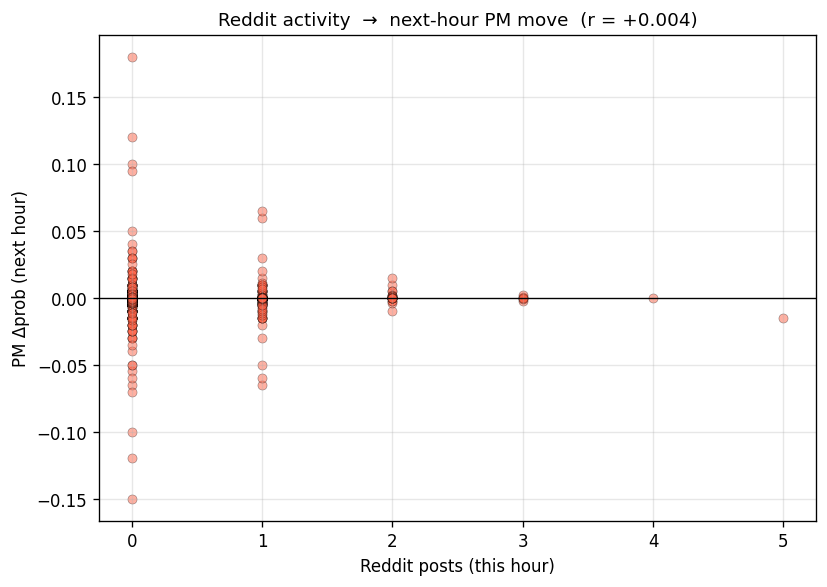

In [10]:

# ── Section 4: Reddit Activity ───────────────────────────────────────────────
df_aligned = make_aligned(STRIKE_FOCAL, DIRECTION)
col_pm     = f"PM {DIRECTION} ${STRIKE_FOCAL}"

# reddit_hourly is a Series (defined in helpers cell)
rh_aligned = reddit_hourly.reindex(df_aligned.index, fill_value=0)

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(df_aligned.index, df_aligned[col_pm], color="steelblue", lw=1.5,
         zorder=3, label=f"PM P({DIRECTION} ${STRIKE_FOCAL})")
ax2.bar(rh_aligned.index, rh_aligned.values, color="tomato", alpha=0.45,
        width=1/24, label="Reddit posts/hr")

ax1.set_ylabel("PM Probability", color="steelblue", fontsize=10)
ax2.set_ylabel("Reddit posts / hr", color="tomato", fontsize=10)
ax1.set_title(f"Reddit Activity vs PM P(CL {DIRECTION} ${STRIKE_FOCAL})", fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/reddit_pm_overlay.png", dpi=150)
plt.show()

# ── Scatter: Reddit posts vs next-hour PM change ──────────────────────────────
df_merged_r = pd.concat([
    df_aligned[col_pm].rename("pm"),
    rh_aligned.rename("reddit_posts"),
], axis=1).dropna()

df_merged_r["pm_chg_next1h"] = df_merged_r["pm"].shift(-1) - df_merged_r["pm"]

corr_r = df_merged_r["reddit_posts"].corr(df_merged_r["pm_chg_next1h"])
print(f"Correlation: Reddit posts/hr  →  PM change next hour: {corr_r:+.4f}")

fig2, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_merged_r["reddit_posts"], df_merged_r["pm_chg_next1h"],
           alpha=0.5, edgecolors="k", lw=0.3, s=30, color="tomato")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Reddit posts (this hour)", fontsize=10)
ax.set_ylabel("PM Δprob (next hour)", fontsize=10)
ax.set_title(f"Reddit activity  →  next-hour PM move  (r = {corr_r:+.3f})", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/scatter_reddit_pm.png", dpi=150)
plt.show()


## 5 · Lead-Lag Cross-Correlation

Rolling cross-correlation between Polymarket hourly returns and NYMEX hourly returns.  
**Positive lag** = PM *leads* NYMEX (PM moves first).  
**Negative lag** = PM *lags* NYMEX (NYMEX moves first).

/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_78387/219588450.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["nymex_pct_chg"] = df["NYMEX close"].pct_change()
/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_78387/1169965188.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  nymex_ret = df_aligned[col_nymex].pct_change().dropna()


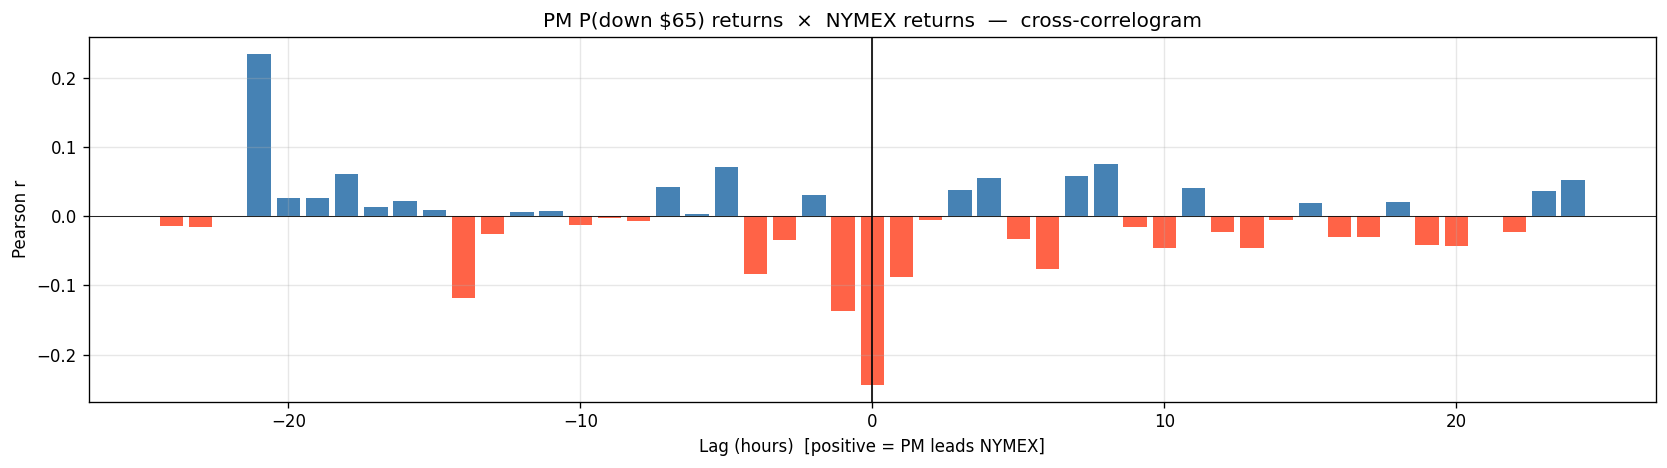

Peak PM×NYMEX xcorr: r = -0.2440  at lag = +0 h
→ Polymarket CONTEMPORANEOUS by 0 hour(s)


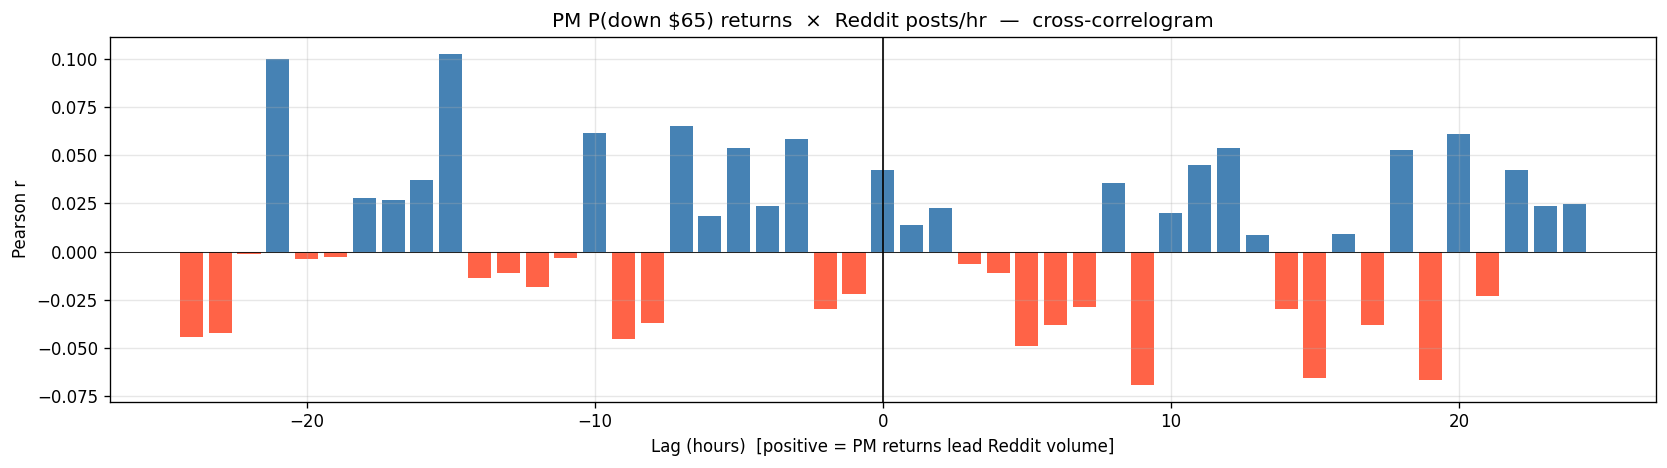


Peak PM×Reddit xcorr: r = +0.1030  at lag = -15 h
→ Polymarket LAGS Reddit by 15 hour(s)


In [11]:

# ── Section 5: Lead-Lag Cross-Correlation ────────────────────────────────────
MAX_LAG    = 24   # hours
df_aligned = make_aligned(STRIKE_FOCAL, DIRECTION)
col_pm     = f"PM {DIRECTION} ${STRIKE_FOCAL}"
col_nymex  = "NYMEX close"

pm_ret    = df_aligned[col_pm].pct_change().dropna()
nymex_ret = df_aligned[col_nymex].pct_change().dropna()
combined  = pd.concat([pm_ret.rename("pm"), nymex_ret.rename("nymex")], axis=1).dropna()

lags   = range(-MAX_LAG, MAX_LAG + 1)
xcorrs = [combined["pm"].corr(combined["nymex"].shift(-lag)) for lag in lags]

# ── PM vs NYMEX cross-correlogram ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(list(lags), xcorrs,
       color=["steelblue" if x >= 0 else "tomato" for x in xcorrs], width=0.8)
ax.axvline(0, color="k", lw=1)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("Lag (hours)  [positive = PM leads NYMEX]", fontsize=10)
ax.set_ylabel("Pearson r", fontsize=10)
ax.set_title(f"PM P({DIRECTION} ${STRIKE_FOCAL}) returns  ×  NYMEX returns  —  cross-correlogram",
             fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/xcorr_pm_nymex.png", dpi=150)
plt.show()

best_lag   = list(lags)[int(np.argmax(np.abs(xcorrs)))]
best_corr  = xcorrs[list(lags).index(best_lag)]
dir_nymex  = "LEADS NYMEX" if best_lag > 0 else ("LAGS NYMEX" if best_lag < 0 else "CONTEMPORANEOUS")
print(f"Peak PM×NYMEX xcorr: r = {best_corr:+.4f}  at lag = {best_lag:+d} h")
print(f"→ Polymarket {dir_nymex} by {abs(best_lag)} hour(s)")

# ── PM vs Reddit cross-correlogram ────────────────────────────────────────────
rh = reddit_hourly.reindex(combined.index, fill_value=0)
xcorrs_r = [combined["pm"].corr(rh.shift(-lag)) for lag in lags]

fig2, ax2 = plt.subplots(figsize=(14, 4))
ax2.bar(list(lags), xcorrs_r,
        color=["steelblue" if x >= 0 else "tomato" for x in xcorrs_r], width=0.8)
ax2.axvline(0, color="k", lw=1)
ax2.axhline(0, color="k", lw=0.5)
ax2.set_xlabel("Lag (hours)  [positive = PM returns lead Reddit volume]", fontsize=10)
ax2.set_ylabel("Pearson r", fontsize=10)
ax2.set_title(f"PM P({DIRECTION} ${STRIKE_FOCAL}) returns  ×  Reddit posts/hr  —  cross-correlogram",
              fontsize=12)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/xcorr_pm_reddit.png", dpi=150)
plt.show()

best_r_lag  = list(lags)[int(np.argmax(np.abs(xcorrs_r)))]
best_r_corr = xcorrs_r[list(lags).index(best_r_lag)]
dir_reddit  = "LEADS Reddit" if best_r_lag > 0 else ("LAGS Reddit" if best_r_lag < 0 else "CONTEMPORANEOUS")
print(f"\nPeak PM×Reddit xcorr: r = {best_r_corr:+.4f}  at lag = {best_r_lag:+d} h")
print(f"→ Polymarket {dir_reddit} by {abs(best_r_lag)} hour(s)")


## 6 · Summary

Consolidated findings for the focal strike.

In [12]:

# ── Section 6: Summary Table ─────────────────────────────────────────────────
# Recompute all metrics (fully standalone — safe to run alone after Kernel Restart)
WINDOW_H  = 4
MAX_LAG   = 24

df_aligned = make_aligned(STRIKE_FOCAL, DIRECTION)
col_pm     = f"PM {DIRECTION} ${STRIKE_FOCAL}"
col_nymex  = "NYMEX close"

pm_ret    = df_aligned[col_pm].pct_change().dropna()
nymex_ret = df_aligned[col_nymex].pct_change().dropna()
combined  = pd.concat([pm_ret.rename("pm"), nymex_ret.rename("nymex")], axis=1).dropna()
rh        = reddit_hourly.reindex(combined.index, fill_value=0)

lags     = range(-MAX_LAG, MAX_LAG + 1)
xcorrs   = [combined["pm"].corr(combined["nymex"].shift(-lag)) for lag in lags]
xcorrs_r = [combined["pm"].corr(rh.shift(-lag))                for lag in lags]

pearson_lag0 = combined["pm"].corr(combined["nymex"])
best_lag      = list(lags)[int(np.argmax(np.abs(xcorrs)))]
best_corr     = xcorrs[list(lags).index(best_lag)]
best_r_lag    = list(lags)[int(np.argmax(np.abs(xcorrs_r)))]
best_r_corr   = xcorrs_r[list(lags).index(best_r_lag)]

# news pre/post (uses `news` loaded in Cell 2)
t_start = df_aligned.index.min()
t_end   = df_aligned.index.max()
news_in_range = news[(news["published_utc"] >= t_start) & (news["published_utc"] <= t_end)]

pre_changes, post_changes = [], []
for _, nrow in news_in_range.iterrows():
    t    = nrow["published_utc"]
    pre  = df_aligned.loc[(df_aligned.index >= t - pd.Timedelta(hours=WINDOW_H)) &
                          (df_aligned.index <  t), col_pm]
    post = df_aligned.loc[(df_aligned.index >  t) &
                          (df_aligned.index <= t + pd.Timedelta(hours=WINDOW_H)), col_pm]
    if len(pre)  > 1: pre_changes.append(pre.iloc[-1]  - pre.iloc[0])
    if len(post) > 1: post_changes.append(post.iloc[-1] - post.iloc[0])

avg_pre  = np.mean(pre_changes)  if pre_changes  else float("nan")
avg_post = np.mean(post_changes) if post_changes else float("nan")

pm_leads = (not pd.isna(avg_pre)) and (not pd.isna(avg_post)) and abs(avg_pre) > abs(avg_post)
leads_str = "YES ✓" if pm_leads else ("NO ✗" if not pd.isna(avg_pre) else "n/a (no news overlap)")

summary = pd.DataFrame([
    {"Metric": "PM–NYMEX Pearson r (lag-0)",
     "Value": f"{pearson_lag0:+.4f}",
     "Interpretation": "Contemporaneous correlation"},
    {"Metric": "PM–NYMEX peak xcorr lag",
     "Value": f"{best_lag:+d} h",
     "Interpretation": f"r={best_corr:+.4f};  PM {'leads' if best_lag > 0 else 'lags'} NYMEX"},
    {"Metric": "PM–Reddit peak xcorr lag",
     "Value": f"{best_r_lag:+d} h",
     "Interpretation": f"r={best_r_corr:+.4f};  PM {'leads' if best_r_lag > 0 else 'lags'} Reddit"},
    {"Metric": f"Avg PM Δprob pre-news  ({WINDOW_H}h)",
     "Value": f"{avg_pre:+.4f}",
     "Interpretation": "PM move BEFORE headline"},
    {"Metric": f"Avg PM Δprob post-news ({WINDOW_H}h)",
     "Value": f"{avg_post:+.4f}",
     "Interpretation": "PM move AFTER headline"},
    {"Metric": "Does Polymarket lead news?",
     "Value": leads_str,
     "Interpretation": "|pre Δ| > |post Δ|  →  leads"},
])

print(f"=== Lead-Lag Summary  |  {DIRECTION.upper()} ${STRIKE_FOCAL}  |  news events in range: {len(news_in_range)} ===\n")
print(summary.to_string(index=False))

try:
    display(summary.style
            .set_caption(f"Lead-Lag Summary — PM P(CL {DIRECTION} ${STRIKE_FOCAL})")
            .set_table_styles([{"selector": "th", "props": [("font-weight", "bold")]}]))
except Exception:
    pass


=== Lead-Lag Summary  |  DOWN $65  |  news events in range: 37 ===

                     Metric   Value               Interpretation
 PM–NYMEX Pearson r (lag-0) -0.2440  Contemporaneous correlation
    PM–NYMEX peak xcorr lag    +0 h    r=-0.2440;  PM lags NYMEX
   PM–Reddit peak xcorr lag   -15 h   r=+0.1030;  PM lags Reddit
Avg PM Δprob pre-news  (4h) -0.0008      PM move BEFORE headline
Avg PM Δprob post-news (4h) -0.0005       PM move AFTER headline
 Does Polymarket lead news?   YES ✓ |pre Δ| > |post Δ|  →  leads


/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_78387/219588450.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["nymex_pct_chg"] = df["NYMEX close"].pct_change()
/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_78387/3757222832.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  nymex_ret = df_aligned[col_nymex].pct_change().dropna()


,Metric,Value,Interpretation
0,PM–NYMEX Pearson r (lag-0),-0.2440,Contemporaneous correlation
1,PM–NYMEX peak xcorr lag,+0 h,r=-0.2440; PM lags NYMEX
2,PM–Reddit peak xcorr lag,-15 h,r=+0.1030; PM lags Reddit
3,Avg PM Δprob pre-news (4h),-0.0008,PM move BEFORE headline
4,Avg PM Δprob post-news (4h),-0.0005,PM move AFTER headline
5,Does Polymarket lead news?,YES ✓,|pre Δ| > |post Δ| → leads
